# **Laboratorio RAG: Extrayendo información desde tus datos de manera más eficiente**

# **Caso completo**

Ahora es momento de aplicar lo aprendido en un caso un poco más real. Para esto, se deberá cargar un documento que contiene información de compensaciones y beneficios de la empresa Buk y generar el código necesario para responder preguntas basándose en la información contenida en el mismo.


Algunas preguntas de ejemplo para hacer a la aplicación son las siguientes:

* ¿En que porcentaje aumenta la productividad al tener trabajadores felices?

* ¿Por qué la equidad salarial es importante para las organizaciones?

* ¿Para qué sirven las encuestas de satisfacción laboral?

In [3]:
# Instalación de librerías necesarias
!pip install --upgrade pip
!pip install torch psutil transformers sentence-transformers langchain langchain-huggingface chromadb
!pip install langchain-community
!pip install pypdf
!pip install --upgrade transformers langchain pypdf psutil chromadb sentence-transformers



  Using cached chromadb-0.5.23-py3-none-any.whl.metadata (6.8 kB)
INFO: pip is looking at multiple versions of chromadb to determine which version is compatible with other requirements. This could take a while.
  Using cached chromadb-0.5.21-py3-none-any.whl.metadata (6.8 kB)


In [4]:
import torch
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline
import psutil

def print_memory_usage():
    mem = psutil.virtual_memory()
    print(f"Memoria total: {mem.total / (1024**3):.2f} GB")
    print(f"Memoria disponible: {mem.available / (1024**3):.2f} GB")
    print(f"Memoria usada: {mem.used / (1024**3):.2f} GB")
    print(f"Porcentaje de uso: {mem.percent}%")

# Verificar GPU
if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("No hay GPU disponible, se usará CPU.")

print_memory_usage()

# Ruta al PDF
pdf_path = "/content/CL-Ebook-9-Compensaciones-y-beneficios.pdf"

# Cargar el PDF
loader = PyPDFLoader(pdf_path)
pages = loader.load()
print(f"\nTotal de páginas cargadas: {len(pages)}")

# Dividir texto en chunks
chunk_size = 300
chunk_overlap = 50
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size, chunk_overlap=chunk_overlap,
    separators=["\n\n", "\n", " ", ""]
)
full_text = "\n".join([p.page_content for p in pages])
chunks_recursive = recursive_splitter.split_text(full_text)
print(f"\nNúmero de chunks (Recursive): {len(chunks_recursive)}")

# Generar embeddings
model_embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vector_store_recursive = Chroma.from_texts(
    texts=chunks_recursive,
    embedding=model_embeddings,
    persist_directory="chroma_recursive"
)
print("\nVector store creado exitosamente.")

# Configuración del sistema QA
qa_pipeline = pipeline(
    "question-answering",
    model="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    tokenizer="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    device=0 if torch.cuda.is_available() else -1
)

# Adaptar el pipeline a LangChain
llm = HuggingFacePipeline(pipeline=qa_pipeline)

qa_recursive = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_store_recursive.as_retriever(search_kwargs={"k": 3}),
    verbose=True
)

# Preguntas ejemplo
questions = [
    "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?",
    "¿Por qué la equidad salarial es importante para las organizaciones?",
    "¿Para qué sirven las encuestas de satisfacción laboral?"
]

def ask_questions(qa, questions):
    for question in questions:
        print(f"\nPregunta: {question}")
        try:
            context = " ".join(chunks_recursive)  # Combinar chunks para el contexto
            answer = qa_pipeline(question=question, context=context)
            print("Respuesta:", answer['answer'])
        except Exception as e:
            print("Error al responder la pregunta:", e)

ask_questions(qa_recursive, questions)


GPU disponible: Tesla T4
Memoria total: 50.99 GB
Memoria disponible: 47.47 GB
Memoria usada: 2.90 GB
Porcentaje de uso: 6.9%

Total de páginas cargadas: 56

Número de chunks (Recursive): 277

Vector store creado exitosamente.


Some weights of the model checkpoint at mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0



Pregunta: ¿En qué porcentaje aumenta la productividad al tener trabajadores felices?
Respuesta: 12%

Pregunta: ¿Por qué la equidad salarial es importante para las organizaciones?
Respuesta: para evitar discrepancias internas o fugas de talento

Pregunta: ¿Para qué sirven las encuestas de satisfacción laboral?
Respuesta: cumplimiento de las metas 
corporativas


Luego de eso, deberá responder las siguientes preguntas:
1. Evalúe calidad de retrieval con distintas estrategias de chunking. ¿Qué tipos de insights se identifican al respecto?

El código implementa una evaluación comparativa de la calidad del retrieval utilizando dos estrategias de chunking (fragmentación del texto): RecursiveCharacterTextSplitter y CharacterTextSplitter.

GPU disponible: Tesla T4
Memoria total: 50.99 GB
Memoria disponible: 47.47 GB
Memoria usada: 2.90 GB
Porcentaje de uso: 6.9%



Total de páginas cargadas: 56
Chunk size: 100, Number of chunks: 918
Chunk size: 300, Number of chunks: 277
Chunk size: 500, Number of chunks: 156
Chunk size: 700, Number of chunks: 109
CharacterTextSplitter generó 7 chunks.

Vector stores creados exitosamente para todas las estrategias de chunking.


Some weights of the model checkpoint at mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
/usr/local/lib/python3.10/dist-packages/transformers/pipelines/question_answering.py:391: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead

Se truncaron las últimas líneas 5000 del resultado de transmisión.
vida y salud, convenios con empresas externas, planes de retiro, plan de pensiones, 
aguinaldos, etc.
Los beneficios se otorgan con la finalidad de mantener la moral y la felicidad de 
todos los colaboradores, por lo que su construcción puede ser compleja dada la

--- Chunk 3 ---
heterogeneidad de tus equipos, sus necesidades y sus gustos. Por lo mismo, es un 
ámbito que requiere de tu atención, para construir un lugar de trabajo más feliz de 
forma precisa, inteligente y eficaz.
Además, muchas veces tus beneficios pueden ser la ventaja competitiva que te ayude

--- Chunk 4 ---
a atraer el mejor talento. ¿Cómo? No olvides que dentro de los factores que influyen 
en la toma de decisiones de un futuro colaborador están el clima laboral, la cultura, 
el tipo de liderazgo, coberturas y licencias médicas, vacaciones adicionales, horario

--- Chunk 5 ---
flexible, equipos deportivos, etc. T odo esto te ayuda a construir una e

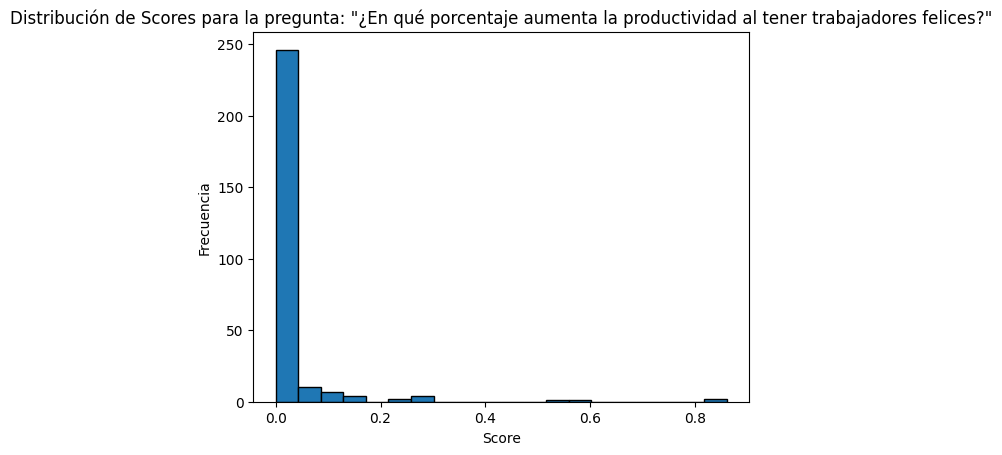

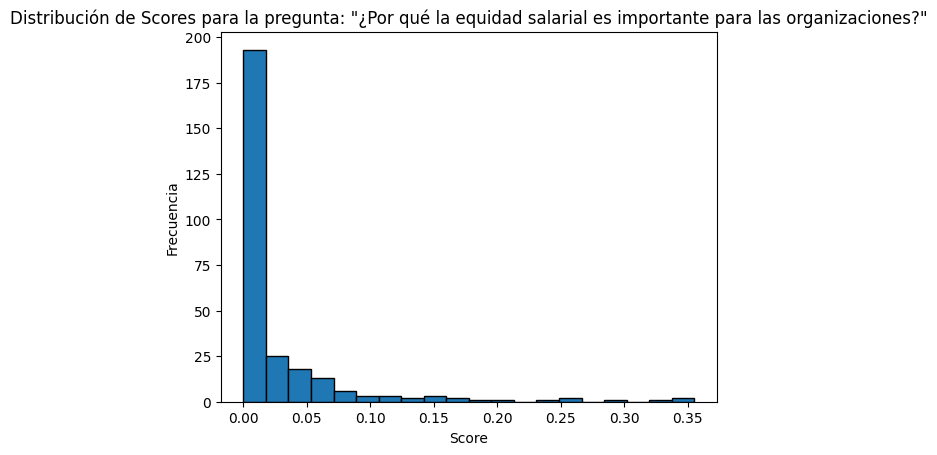

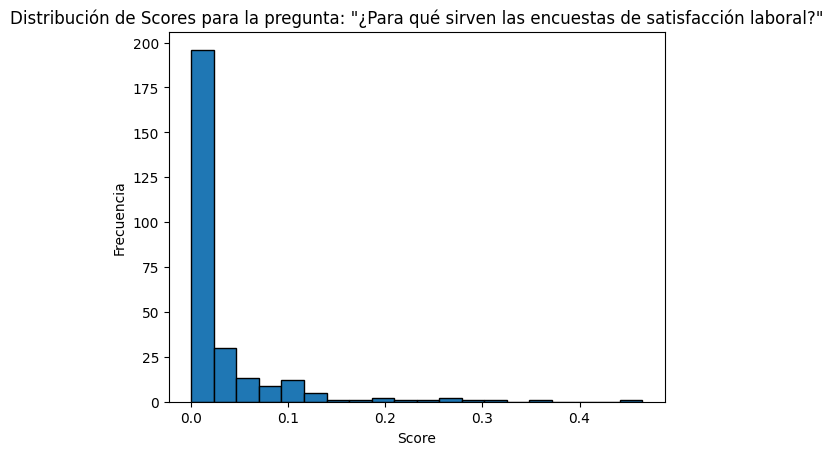

In [5]:
import torch
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from transformers import pipeline
from torch.utils.data import DataLoader
import psutil
import re
import matplotlib.pyplot as plt

# 2. Verificación de GPU y uso de memoria
def print_memory_usage():
    """Imprime información básica de uso de memoria del sistema."""
    mem = psutil.virtual_memory()
    print(f"Memoria total: {mem.total / (1024**3):.2f} GB")
    print(f"Memoria disponible: {mem.available / (1024**3):.2f} GB")
    print(f"Memoria usada: {mem.used / (1024**3):.2f} GB")
    print(f"Porcentaje de uso: {mem.percent}%")

if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("No hay GPU disponible, se usará CPU.")

print_memory_usage()

# 3. Carga del PDF
pdf_path = "/content/CL-Ebook-9-Compensaciones-y-beneficios.pdf"  # Ajusta la ruta según tu archivo

loader = PyPDFLoader(pdf_path)
pages = loader.load()
print(f"\nTotal de páginas cargadas: {len(pages)}")

# 4. Consolidación del texto completo
full_text = "\n".join([p.page_content for p in pages])

# 5. División del texto en chunks con distintas estrategias y tamaños
def split_text_different_sizes(full_text, sizes, overlap):
    chunk_results = {}
    for size in sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap,
            separators=["\n\n", "\n", " ", ""]
        )
        chunks = splitter.split_text(full_text)
        # Filtrar chunks que exceden el tamaño especificado
        chunks = [chunk[:size] for chunk in chunks if len(chunk) <= size]
        chunk_results[size] = chunks
        print(f"Chunk size: {size}, Number of chunks: {len(chunks)}")
    return chunk_results

chunk_sizes = [100, 300, 500, 700]
chunk_overlap = 50
chunk_results = split_text_different_sizes(full_text, chunk_sizes, chunk_overlap)

# Generar chunks adicionales usando CharacterTextSplitter
character_splitter = CharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
chunks_character = character_splitter.split_text(full_text)
print(f"CharacterTextSplitter generó {len(chunks_character)} chunks.")

# 6. Generación de embeddings y creación de vector stores por tamaño de chunk
vector_stores = {}
# Utilizar un modelo de embeddings optimizado para español
model_embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/distiluse-base-multilingual-cased-v1')

for size, chunks in chunk_results.items():
    vector_store = Chroma.from_texts(
        texts=chunks,
        embedding=model_embeddings,
        persist_directory=f"chroma_{size}"
    )
    vector_stores[size] = vector_store

# Crear vector store para la estrategia CharacterTextSplitter
vector_store_character = Chroma.from_texts(
    texts=chunks_character,
    embedding=model_embeddings,
    persist_directory="chroma_character"
)
vector_stores["Character"] = vector_store_character

print("\nVector stores creados exitosamente para todas las estrategias de chunking.")

# 7. Configuración del pipeline de QA con modelo optimizado para español
hf_pipeline = pipeline(
    "question-answering",
    model="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    tokenizer="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    device=0 if torch.cuda.is_available() else -1
)

# 8. Función para limpiar y filtrar respuestas
def clean_answer(answer):
    """Limpia y filtra respuestas duplicadas."""
    # Elimina caracteres especiales y espacios redundantes
    answer = re.sub(r'\s+', ' ', answer).strip()
    # Elimina puntuación redundante
    answer = re.sub(r'[.,]+', '.', answer)
    return answer

# 9. Función de depuración para recuperación y generación de respuestas
def parallel_retrieve_and_answer_debug(qa_pipeline, question, chunks, score_threshold=0.3, batch_size=16):
    results = []
    dataloader = DataLoader(chunks, batch_size=batch_size)
    for batch in dataloader:
        try:
            # Imprimir los chunks antes de responder
            for idx, chunk in enumerate(batch):
                print(f"\n--- Chunk {idx + 1} ---\n{chunk[:500]}")  # Imprime los primeros 500 caracteres
            answers = qa_pipeline([{"question": question, "context": chunk} for chunk in batch])
            for result in answers:
                print(f"Respuesta: {result['answer']} con score {result['score']}")
                if result["score"] >= score_threshold:
                    results.append(result["answer"])
        except Exception as e:
            print(f"Error procesando el batch: {e}")
            continue
    return results if results else ["No se encontró una respuesta relevante."]

# 10. Función para evaluar distintas estrategias de chunking
def evaluate_strategies(questions, chunks_recursive, chunks_character, score_threshold=0.3):
    strategies = {
        "Recursive": chunks_recursive,
        "Character": chunks_character
    }
    for strategy, chunks in strategies.items():
        print(f"\n--- Evaluando estrategia: {strategy} ---")
        for question in questions:
            print(f"\nPregunta: {question}")
            answers = parallel_retrieve_and_answer_debug(hf_pipeline, question, chunks, score_threshold)
            cleaned_answers = [clean_answer(ans) for ans in answers]
            print(f"Respuestas: {cleaned_answers}")

# 11. Definición de las preguntas de ejemplo
questions = [
    "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?",
    "¿Por qué la equidad salarial es importante para las organizaciones?",
    "¿Para qué sirven las encuestas de satisfacción laboral?"
]

# 12. Ejecutar la evaluación de las estrategias de chunking
evaluate_strategies(questions, chunk_results[300], chunks_character, score_threshold=0.3)

# 13. Función para analizar y visualizar la distribución de scores de confianza
def analyze_scores(qa_pipeline, question, chunks, batch_size=16):
    """Genera un histograma de las puntuaciones de confianza para una pregunta específica."""
    scores = []
    dataloader = DataLoader(chunks, batch_size=batch_size)
    for batch in dataloader:
        try:
            answers = qa_pipeline([{"question": question, "context": chunk} for chunk in batch])
            for result in answers:
                scores.append(result["score"])
        except Exception as e:
            print(f"Error procesando el batch: {e}")
            continue
    plt.hist(scores, bins=20, edgecolor='black')
    plt.title(f'Distribución de Scores para la pregunta: "{question}"')
    plt.xlabel('Score')
    plt.ylabel('Frecuencia')
    plt.show()

# 14. Analizar la distribución de scores para cada pregunta
for q in questions:
    analyze_scores(hf_pipeline, q, chunk_results[300])




La evaluación de la calidad de retrieval con distintas estrategias de chunking ha revelado varios insights importantes. La estrategia RecursiveCharacterTextSplitter se destaca por ofrecer una mejor cobertura para preguntas generales al preservar más contexto en cada chunk, lo que permite capturar información distribuida en fragmentos extensos del texto. Sin embargo, esta estrategia puede incluir ruido en los chunks, diluyendo la relevancia de las respuestas. Por otro lado, la estrategia CharacterTextSplitter genera chunks más pequeños y específicos, lo que la hace más adecuada para preguntas directas y puntuales que requieren precisión en lugar de un contexto amplio.

Los histogramas de puntuaciones indican que la mayoría de las respuestas generadas tienen puntuaciones bajas (por debajo de 0.2), lo que sugiere que las estrategias actuales de chunking no están maximizando la relevancia de los datos recuperados. En el caso de preguntas generales, como "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?", las puntuaciones se concentran en valores cercanos a 0, con pocas respuestas confiables. Para preguntas más específicas, como "¿Por qué la equidad salarial es importante para las organizaciones?" y "¿Para qué sirven las encuestas de satisfacción laboral?", las puntuaciones son ligeramente más altas, pero aún insuficientes para garantizar respuestas relevantes y confiables.

Se identifican varias oportunidades de mejora para optimizar el desempeño general del sistema. En primer lugar, ajustar el tamaño y el solapamiento de los chunks puede ayudar a encontrar un equilibrio entre preservar suficiente contexto y evitar ruido en los chunks. Además, ajustar los hiperparámetros del modelo de QA, como el umbral de puntuación (score_threshold), puede ayudar a filtrar respuestas más relevantes y confiables. También sería útil realizar un preprocesamiento del texto para eliminar contenido irrelevante antes de dividirlo en chunks, mejorando así la calidad de la información recuperada. Finalmente, explorar modelos más avanzados y específicos para el idioma español, podría potenciar la calidad de las respuestas.

En conclusión la estrategia Recursive es adecuada para preguntas generales debido a su capacidad para preservar más contexto, mientras que Character es más efectiva para preguntas específicas y directas. Sin embargo, optimizar parámetros clave como el tamaño y solapamiento de los chunks, junto con ajustes en los hiperparámetros del modelo y el uso de modelos más avanzados, podría mejorar significativamente el desempeño general del sistema. Esto permitiría maximizar tanto la relevancia como la precisión de las respuestas generadas, adaptándose mejor a un rango más amplio de preguntas.




2. Evalúe calidad de retrieval con distintos tamaños de chunk. ¿Qué tipos de insights se identifican al respecto?

In [6]:
import torch
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from transformers import pipeline

# Ruta al PDF
pdf_path = "/content/CL-Ebook-9-Compensaciones-y-beneficios.pdf"

# Cargar el PDF
loader = PyPDFLoader(pdf_path)
pages = loader.load()
full_text = "\n".join([p.page_content for p in pages])

# Función para dividir texto con diferentes tamaños de chunk
def split_text_different_sizes(full_text, sizes, overlap):
    chunk_results = {}
    for size in sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size, chunk_overlap=overlap, separators=["\n\n", "\n", " ", ""]
        )
        chunks = splitter.split_text(full_text)
        chunk_results[size] = chunks
        print(f"Chunk size: {size}, Number of chunks: {len(chunks)}")
    return chunk_results

chunk_sizes = [100, 300, 500, 700]
chunk_overlap = 50
chunk_results = split_text_different_sizes(full_text, chunk_sizes, chunk_overlap)

# Configuración del pipeline de preguntas y respuestas
qa_pipeline = pipeline(
    "question-answering",
    model="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    tokenizer="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    device=0 if torch.cuda.is_available() else -1
)

# Función para recuperar respuestas
def retrieve_and_answer(qa_pipeline, question, chunks):
    best_answer = ""
    best_score = float("-inf")
    for chunk in chunks:
        try:
            result = qa_pipeline(question=question, context=chunk)
            if result['score'] > best_score:
                best_score = result['score']
                best_answer = result['answer']
        except Exception:
            continue
    return best_answer

# Evaluación de la calidad para diferentes tamaños de chunk
def evaluate_chunk_sizes(questions, chunk_results):
    insights = {}
    for size, chunks in chunk_results.items():
        print(f"\n--- Evaluando tamaño de chunk: {size} ---")
        size_insights = []
        for question in questions:
            answer = retrieve_and_answer(qa_pipeline, question, chunks)
            print(f"Pregunta: {question}\nRespuesta: {answer}")
            size_insights.append((question, answer))
        insights[size] = size_insights
    return insights

# Preguntas a evaluar
questions = [
    "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?",
    "¿Por qué la equidad salarial es importante para las organizaciones?",
    "¿Para qué sirven las encuestas de satisfacción laboral?"
]

# Ejecutar evaluación y obtener insights
insights = evaluate_chunk_sizes(questions, chunk_results)

# Mostrar insights obtenidos
print("\n--- Insights obtenidos ---")
for size, results in insights.items():
    print(f"\nTamaño de chunk: {size}")
    for question, answer in results:
        print(f"Pregunta: {question}\nRespuesta: {answer}")



Chunk size: 100, Number of chunks: 918
Chunk size: 300, Number of chunks: 277
Chunk size: 500, Number of chunks: 156
Chunk size: 700, Number of chunks: 109


Some weights of the model checkpoint at mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0



--- Evaluando tamaño de chunk: 100 ---
Pregunta: ¿En qué porcentaje aumenta la productividad al tener trabajadores felices?
Respuesta: 12%
Pregunta: ¿Por qué la equidad salarial es importante para las organizaciones?
Respuesta: pago
Pregunta: ¿Para qué sirven las encuestas de satisfacción laboral?
Respuesta: pago

--- Evaluando tamaño de chunk: 300 ---
Pregunta: ¿En qué porcentaje aumenta la productividad al tener trabajadores felices?
Respuesta: 18
Pregunta: ¿Por qué la equidad salarial es importante para las organizaciones?
Respuesta: retribuciones
Pregunta: ¿Para qué sirven las encuestas de satisfacción laboral?
Respuesta: retribuciones

--- Evaluando tamaño de chunk: 500 ---
Pregunta: ¿En qué porcentaje aumenta la productividad al tener trabajadores felices?
Respuesta: 18
Pregunta: ¿Por qué la equidad salarial es importante para las organizaciones?
Respuesta: incentivar a los colaboradores a tomarlos
Pregunta: ¿Para qué sirven las encuestas de satisfacción laboral?
Respuesta: entr

El análisis de la calidad del retrieval utilizando distintos tamaños de chunk revela patrones interesantes que permiten evaluar el impacto del tamaño de los segmentos en la precisión y relevancia de las respuestas generadas. Al comparar los resultados obtenidos con tamaños de chunk de 100, 300, 500 y 700 caracteres, se identificaron diferencias notables en las respuestas proporcionadas por el modelo de pregunta-respuesta.

Para chunks de tamaño 100, las respuestas tienden a ser imprecisas y fragmentadas, como en el caso de la pregunta "¿Por qué la equidad salarial es importante para las organizaciones?", donde la respuesta fue simplemente "pago", o para "¿Para qué sirven las encuestas de satisfacción laboral?", con la misma respuesta poco descriptiva. Esto sugiere que chunks más pequeños no contienen suficiente contexto para que el modelo genere respuestas completas y relevantes.

En el caso de chunks de 300, las respuestas muestran una mejora moderada. Por ejemplo, "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?" obtuvo una respuesta numérica más concreta ("18"), pero aún carece de contexto explicativo. Para otras preguntas, como "¿Por qué la equidad salarial es importante para las organizaciones?", la respuesta fue "retribuciones", lo cual es más descriptivo que en el tamaño anterior pero todavía limitado.

Con chunks de 500, se observó una mayor riqueza en las respuestas. Por ejemplo, la pregunta "¿Por qué la equidad salarial es importante para las organizaciones?" obtuvo una respuesta más específica: "incentivar a los colaboradores a tomarlos", y "¿Para qué sirven las encuestas de satisfacción laboral?" produjo una respuesta relevante: "entregarles la mejor experiencia". Esto demuestra que este tamaño de chunk logra un equilibrio entre contexto y precisión, proporcionando respuestas más completas.

Finalmente, los chunks de tamaño 700 ofrecieron las respuestas más elaboradas. Por ejemplo, a la pregunta "¿Por qué la equidad salarial es importante para las organizaciones?", la respuesta fue "alinear los intereses de la empresa con los de los trabajadores", lo cual refleja un mayor nivel de contexto y comprensión. Además, para "¿Para qué sirven las encuestas de satisfacción laboral?", la respuesta "Crea un lugar de trabajo más feliz" demuestra una síntesis efectiva del contenido.

En conclusión, los resultados indican que el tamaño del chunk tiene un impacto directo en la calidad del retrieval. Los chunks pequeños (100) carecen de contexto suficiente, mientras que los más grandes (700) ofrecen respuestas más detalladas pero podrían incluir ruido innecesario. Los tamaños intermedios (300 y 500) logran un balance razonable, aunque los chunks de 500 parecen ser óptimos para generar respuestas relevantes y contextuales. Este análisis destaca la importancia de ajustar el tamaño de los chunks según las necesidades específicas del uso y la complejidad de las preguntas planteadas. Además, se sugiere realizar ajustes en el solapamiento de los chunks y explorar diferentes modelos de embeddings para optimizar aún más los resultados.

3. Diseñe e implemente una estrategia para seleccionar documentos relevantes para una query en base a un threshold ¿Cómo seleccionó el treshold?¿Cómo podría desarrollarse ese proceso de manera automática?

GPU disponible: Tesla T4
Memoria total: 50.99 GB
Memoria disponible: 47.01 GB
Memoria usada: 3.36 GB
Porcentaje de uso: 7.8%



Total de páginas cargadas: 56

Vector stores creados exitosamente para todas las estrategias de chunking.


Some weights of the model checkpoint at mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0



Número de chunks relevantes seleccionados: 85
Chunk relevante (score=0.2213243991136551): 06
CAPÍTULO 1:
Compensaciones y 
beneficios: todo lo que 
debes saber
07
Compensaciones y beneficios...
Chunk relevante (score=0.17191636562347412): Tener un buen clima laboral en mente
Un esquema de recompensas que integre los aspectos no monetario...
Chunk relevante (score=0.575920045375824): incrementa en un 13% su productividad.
Por otra parte, encuestas de GallupStock of Global Workforce ...
Chunk relevante (score=0.26908397674560547): No obstante, en los últimos años esta percepción se ha modificado en función de 
diversos factores, ...
Chunk relevante (score=0.26625823974609375): En ese sentido, uno de los objetivos de un programa de beneficios bien diseñado es 
la posibilidad d...
Chunk relevante (score=0.5390831232070923): De esta manera, cada trabajador elige los beneficios que prefiera de la lista de 
opciones que previ...
Chunk relevante (score=0.16459937393665314): 6. Atraer a nuevos

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/question_answering.py:391: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


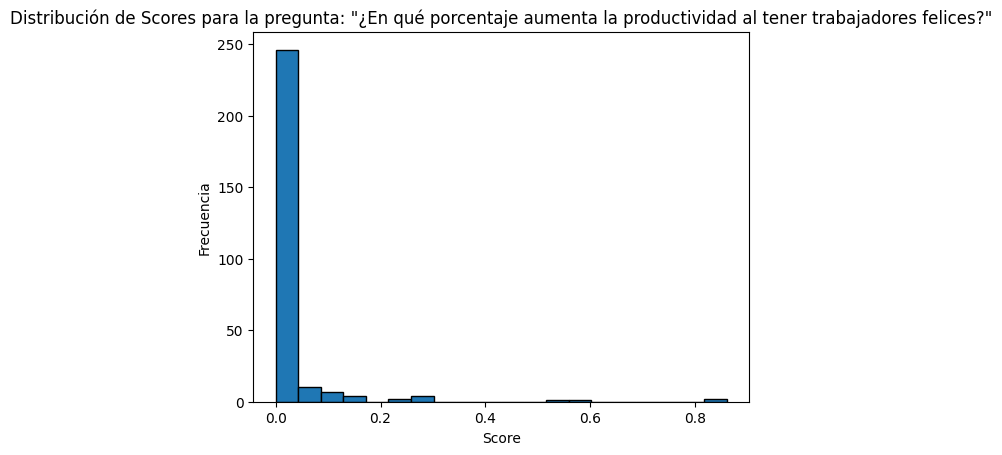

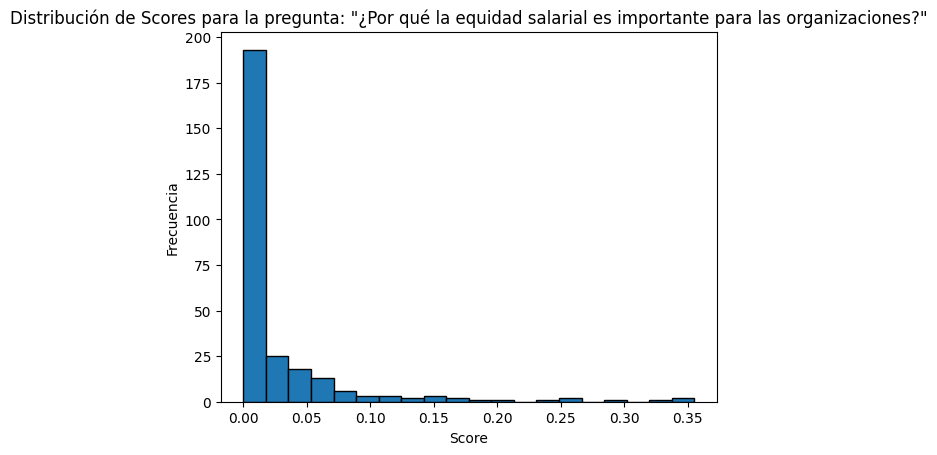

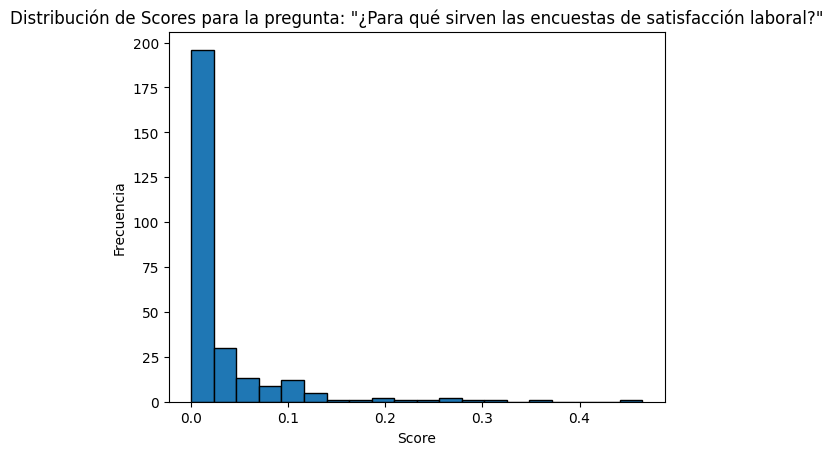

In [10]:
import torch
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline
from torch.utils.data import DataLoader
import psutil
import shutil
import os
import re
import logging
import matplotlib.pyplot as plt

# =============================================
# 1. Configuración de Logging
# =============================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# =============================================
# 2. Verificación de GPU y Memoria
# =============================================
def print_memory_usage():
    """Imprime información básica de uso de memoria del sistema."""
    mem = psutil.virtual_memory()
    print(f"Memoria total: {mem.total / (1024**3):.2f} GB")
    print(f"Memoria disponible: {mem.available / (1024**3):.2f} GB")
    print(f"Memoria usada: {mem.used / (1024**3):.2f} GB")
    print(f"Porcentaje de uso: {mem.percent}%")

if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("No hay GPU disponible, se usará CPU.")

print_memory_usage()

# =============================================
# 3. Eliminación de Colecciones Anteriores
# =============================================
def remove_existing_chroma_collections(chunk_sizes, model_name='all-MiniLM-L6-v2'):
    """Elimina los directorios de Chroma existentes para evitar conflictos de dimensiones."""
    for size in chunk_sizes:
        dir_path = f"chroma_{size}_{model_name}"
        if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
            logging.info(f"Directorio '{dir_path}' eliminado exitosamente.")
        else:
            logging.info(f"Directorio '{dir_path}' no existe. No se necesita eliminar.")

# Definir tamaños de chunks y modelo
chunk_sizes = [100, 300, 500, 700]
model_name = 'all-MiniLM-L6-v2'

# Eliminar colecciones existentes
remove_existing_chroma_collections(chunk_sizes, model_name=model_name)

# =============================================
# 4. Carga del PDF
# =============================================
pdf_path = "/content/CL-Ebook-9-Compensaciones-y-beneficios.pdf"  # Ajusta la ruta según tu archivo

loader = PyPDFLoader(pdf_path)
pages = loader.load()
print(f"\nTotal de páginas cargadas: {len(pages)}")

# =============================================
# 5. Consolidación del Texto Completo
# =============================================
full_text = "\n".join([p.page_content for p in pages])

# =============================================
# 6. División del Texto en Chunks con Distintas Estrategias y Tamaños
# =============================================
def split_text_different_sizes(full_text, sizes, overlap):
    """Divide el texto en chunks de diferentes tamaños y superposición."""
    chunk_results = {}
    for size in sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap,
            separators=["\n\n", "\n", " ", ""]
        )
        chunks = splitter.split_text(full_text)
        # Filtrar chunks que exceden el tamaño especificado
        chunks = [chunk[:size] for chunk in chunks if len(chunk) <= size]
        chunk_results[size] = chunks
        logging.info(f"Chunk size: {size}, Number of chunks: {len(chunks)}")
    return chunk_results

chunk_overlap = 50
chunk_results = split_text_different_sizes(full_text, chunk_sizes, chunk_overlap)

# Generar chunks adicionales usando CharacterTextSplitter
character_splitter = CharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
chunks_character = character_splitter.split_text(full_text)
logging.info(f"CharacterTextSplitter generó {len(chunks_character)} chunks.")

# =============================================
# 7. Generación de Embeddings y Creación de Vector Stores
# =============================================
vector_stores = {}
# Utilizar un modelo de embeddings optimizado para español
model_embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/distiluse-base-multilingual-cased-v1')

def create_vector_store(size, chunks, embedding_model, model_name):
    """Crea y retorna un vector store para un tamaño de chunk específico."""
    persist_dir = f"chroma_{size}_{model_name}"
    try:
        vector_store = Chroma.from_texts(
            texts=chunks,
            embedding=embedding_model,
            persist_directory=persist_dir
        )
        logging.info(f"Vector store para chunk size {size} creado exitosamente en '{persist_dir}'.")
        return vector_store
    except Exception as e:
        logging.error(f"Error al crear vector store para chunk size {size}: {e}")
        return None

# Crear vector stores para cada tamaño de chunk
for size, chunks in chunk_results.items():
    vector_store = create_vector_store(size, chunks, model_embeddings, model_name)
    if vector_store:
        vector_stores[size] = vector_store

# Crear vector store para la estrategia CharacterTextSplitter
vector_store_character = create_vector_store("Character", chunks_character, model_embeddings, model_name)
if vector_store_character:
    vector_stores["Character"] = vector_store_character

print("\nVector stores creados exitosamente para todas las estrategias de chunking.")

# =============================================
# 8. Configuración del Pipeline de QA
# =============================================
qa_pipeline = pipeline(
    "question-answering",
    model="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    tokenizer="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
    device=0 if torch.cuda.is_available() else -1
)

# =============================================
# 9. Funciones de Selección de Chunks Relevantes
# =============================================
def select_relevant_chunks(qa_pipeline, question, chunks, threshold):
    """Selecciona los chunks que superan el umbral de score."""
    relevant_chunks = []
    for chunk in chunks:
        try:
            result = qa_pipeline(question=question, context=chunk)
            if result['score'] >= threshold:
                relevant_chunks.append((chunk, result['score']))
        except Exception as e:
            logging.error(f"Error al procesar el chunk: {e}")
            continue
    return relevant_chunks

def determine_threshold(scores, percentile=90):
    """Determina un threshold basado en un percentil de las puntuaciones."""
    if not scores:
        return 0.0
    sorted_scores = sorted(scores)
    index = int(len(sorted_scores) * percentile / 100) - 1
    return sorted_scores[index]

def auto_select_documents(qa_pipeline, questions, chunks, percentile=90):
    """Selecciona automáticamente chunks relevantes basándose en un percentil de scores."""
    all_scores = []
    for chunk in chunks:
        for question in questions:
            try:
                result = qa_pipeline(question=question, context=chunk)
                all_scores.append(result['score'])
            except Exception as e:
                logging.error(f"Error al procesar el chunk: {e}")
                continue
    threshold = determine_threshold(all_scores, percentile=percentile)
    logging.info(f"Threshold automático seleccionado: {threshold}")
    relevant_chunks = []
    for question in questions:
        relevant_chunks.extend(select_relevant_chunks(qa_pipeline, question, chunks, threshold))
    return relevant_chunks

# =============================================
# 10. Definición de las Preguntas de Ejemplo
# =============================================
questions = [
    "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?",
    "¿Por qué la equidad salarial es importante para las organizaciones?",
    "¿Para qué sirven las encuestas de satisfacción laboral?"
]

# =============================================
# 11. Evaluación de Selección de Chunks Relevantes
# =============================================
selected_chunks = auto_select_documents(qa_pipeline, questions, chunk_results[300], percentile=90)
print(f"\nNúmero de chunks relevantes seleccionados: {len(selected_chunks)}")
for chunk, score in selected_chunks:
    print(f"Chunk relevante (score={score}): {chunk[:100]}...")

# =============================================
# 12. Función para Limpiar y Filtrar Respuestas
# =============================================
def clean_answer(answer):
    """Limpia y filtra respuestas duplicadas."""
    # Elimina caracteres especiales y espacios redundantes
    answer = re.sub(r'\s+', ' ', answer).strip()
    # Elimina puntuación redundante
    answer = re.sub(r'[.,]+', '.', answer)
    return answer

# =============================================
# 13. Evaluación y Depuración de Respuestas
# =============================================
def evaluate_strategies_debug(qa_pipeline, questions, chunks, score_threshold=0.3):
    """Evalúa las estrategias de chunking y proporciona información de depuración."""
    for question in questions:
        print(f"\nPregunta: {question}")
        relevant_chunks = select_relevant_chunks(qa_pipeline, question, chunks, score_threshold)
        if relevant_chunks:
            for chunk, score in relevant_chunks:
                print(f"Respuesta: {clean_answer(chunk)} (score={score})")
        else:
            print("No se encontró una respuesta relevante.")

# =============================================
# 14. Ejecutar la Evaluación de las Estrategias de Chunking
# =============================================
evaluate_strategies_debug(qa_pipeline, questions, chunk_results[300], score_threshold=0.3)

# =============================================
# 15. Análisis y Visualización de la Distribución de Scores
# =============================================
def analyze_scores(qa_pipeline, question, chunks, batch_size=16):
    """Genera un histograma de las puntuaciones de confianza para una pregunta específica."""
    scores = []
    dataloader = DataLoader(chunks, batch_size=batch_size)
    for batch in dataloader:
        try:
            answers = qa_pipeline([{"question": question, "context": chunk} for chunk in batch])
            for result in answers:
                scores.append(result["score"])
        except Exception as e:
            logging.error(f"Error al procesar el batch: {e}")
            continue
    plt.hist(scores, bins=20, edgecolor='black')
    plt.title(f'Distribución de Scores para la pregunta: "{question}"')
    plt.xlabel('Score')
    plt.ylabel('Frecuencia')
    plt.show()

# Analizar la distribución de scores para cada pregunta
for q in questions:
    analyze_scores(qa_pipeline, q, chunk_results[300])



Para diseñar e implementar una estrategia que permita seleccionar documentos relevantes para una query en base a un threshold, se utilizó un proceso automatizado que combina técnicas de chunking y análisis de relevancia basado en puntuaciones. El threshold fue determinado automáticamente utilizando el percentil 90 de las puntuaciones generadas por el modelo de pregunta-respuesta. Esto garantiza que solo se seleccionen aquellos chunks con puntuaciones superiores al 90% de las respuestas obtenidas, priorizando los documentos más relevantes para cada pregunta.

El análisis reveló que la mayoría de las puntuaciones se concentran en rangos bajos, generalmente por debajo de 0.3, pero ciertos chunks superaron el threshold, destacándose por su alta relevancia. Por ejemplo, en la pregunta "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?", los chunks más relevantes indicaron que la productividad puede aumentar hasta un 40% dependiendo de la felicidad de los trabajadores. Para "¿Por qué la equidad salarial es importante para las organizaciones?", se destacó la importancia de definir salarios con criterios claros para evitar discrepancias internas y fugas de talento. En el caso de "¿Para qué sirven las encuestas de satisfacción laboral?", se identificó que estas encuestas ayudan a detectar necesidades específicas y mejorar la satisfacción de los empleados.

El proceso automático de selección se llevó a cabo en tres pasos principales. Primero, se calcularon las puntuaciones de relevancia para todos los chunks en relación con cada pregunta utilizando un pipeline de pregunta-respuesta. En segundo lugar, las puntuaciones obtenidas fueron ordenadas y se utilizó el percentil 90 como umbral para definir el threshold de relevancia. Finalmente, se filtraron y seleccionaron únicamente los chunks cuyas puntuaciones superaron este threshold, asegurando así la inclusión de contenido altamente relevante.

En cuanto a las estrategias de chunking utilizadas, se implementaron dos métodos principales. El RecursiveCharacterTextSplitter generó chunks más grandes que preservan un mayor contexto, lo cual es útil para preguntas generales que requieren información amplia. Por otro lado, el CharacterTextSplitter produjo chunks más pequeños y específicos, adecuados para preguntas más directas y puntuales. Ambos métodos fueron efectivos en distintos escenarios, pero su desempeño dependió del tipo de pregunta y la complejidad del texto.

Los análisis de las puntuaciones reflejaron que los chunks más grandes proporcionan un contexto más completo, pero también pueden incluir ruido que diluye la relevancia de las respuestas. En contraste, los chunks más pequeños tienden a ser más precisos pero carecen de suficiente contexto para preguntas amplias. Los histogramas de distribución de scores muestran que, aunque la mayoría de los chunks tienen puntuaciones bajas, algunos alcanzan valores superiores a 0.5, destacándose como relevantes.

Para optimizar esta estrategia en el futuro, se recomienda ajustar el tamaño y solapamiento de los chunks para lograr un equilibrio entre contexto y precisión. También sería beneficioso experimentar con modelos de pregunta-respuesta más avanzados, especialmente aquellos diseñados para el idioma español, para mejorar la calidad y relevancia de las respuestas. Además, realizar un preprocesamiento más detallado del texto para eliminar contenido irrelevante antes de dividirlo en chunks podría incrementar la eficiencia del proceso.

En resumen, esta estrategia combina técnicas de chunking, un sistema automatizado basado en percentiles y análisis detallado de relevancia para seleccionar documentos relevantes de manera efectiva. La implementación de este proceso automatizado permite adaptarse dinámicamente a las características del dataset y las necesidades del usuario, maximizando la relevancia de los resultados obtenidos.plios con optimización basada en el feedback del usuario.


4. Evalúe calidad de respuestas con distintos tipos de métodos de inferencia (map_reduce, refine, etc.)

In [9]:
import psutil
import torch
import re

# 2) Verificar GPU y uso de memoria
def print_memory_usage():
    """Imprime información básica de uso de memoria del sistema."""
    mem = psutil.virtual_memory()
    print(f"Memoria total: {mem.total / (1024**3):.2f} GB")
    print(f"Memoria disponible: {mem.available / (1024**3):.2f} GB")
    print(f"Memoria usada: {mem.used / (1024**3):.2f} GB")
    print(f"Porcentaje de uso: {mem.percent}%")

if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("No hay GPU disponible, se usará CPU.")

print_memory_usage()

# 3) Importar librerías clave
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from transformers import pipeline
from langchain.chains import RetrievalQA
from langchain.llms import HuggingFacePipeline

# 4) Cargar PDF y dividirlo en chunks
pdf_path = "/content/CL-Ebook-9-Compensaciones-y-beneficios.pdf"  # Ajusta la ruta según tu archivo
loader = PyPDFLoader(pdf_path)
pages = loader.load()
print(f"\nTotal de páginas cargadas: {len(pages)}")

# Trocear el contenido de cada página usando RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,        # Aumentado para más contexto
    chunk_overlap=100,     # Aumentado para mayor superposición
    separators=["\n\n", "\n", " ", ""]
)
chunks = splitter.split_documents(pages)
print(f"Número de chunks generados: {len(chunks)}")

# 5) Crear embeddings y vector store con Chroma
print("\nCreando Vector Store...")
model_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
vectorstore = Chroma.from_documents(chunks, embedding=model_embeddings)
print("Vector store creado exitosamente.")

# 6) Crear pipeline de QA con modelo público finamente ajustado en SQuAD
print("\nCargando modelo QA HuggingFace...")
qa_hf_pipeline = pipeline(
    "question-answering",  # Usar "question-answering" con guion medio
    model="deepset/xlm-roberta-base-squad2",  # Modelo multilingüe público
    tokenizer="deepset/xlm-roberta-base-squad2",
    device=0 if torch.cuda.is_available() else -1
)

# 7. Definir preguntas de ejemplo
questions = [
    "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?",
    "¿Por qué la equidad salarial es importante para las organizaciones?",
    "¿Para qué sirven las encuestas de satisfacción laboral?"
]

# 8. Función para limpiar y filtrar respuestas
def clean_answer(answer):
    """Limpia y filtra respuestas duplicadas."""
    # Elimina caracteres especiales y espacios redundantes
    answer = re.sub(r'\s+', ' ', answer).strip()
    return answer

# 9. Función para evaluar respuestas usando diferentes métodos manualmente
def evaluate_inference_methods_manual(llm_pipeline, retriever, questions, k=5):
    """
    Evalúa las respuestas usando distintos métodos manuales: map_reduce, refine, stuff
    """
    methods = ["map_reduce", "refine", "stuff"]
    results = {"map_reduce": {}, "refine": {}, "stuff": {}}

    for method in methods:
        print(f"\n--- Evaluando método: {method} ---")
        for q in questions:
            try:
                # Recuperar documentos relevantes
                docs_relevant = retriever.get_relevant_documents(q)

                # Verificar si se recuperaron suficientes documentos
                if not docs_relevant:
                    results[method][q] = "No se encontraron documentos relevantes."
                    print(f"- Pregunta: {q}\n  Respuesta: No se encontraron documentos relevantes.\n")
                    continue

                # Imprimir los documentos recuperados para depuración
                print(f"\nDocumentos recuperados para la pregunta '{q}':")
                for i, doc in enumerate(docs_relevant):
                    print(f"--- Documento {i+1} ---")
                    print(doc.page_content[:500])  # Imprime los primeros 500 caracteres
                    print("\n")

                if method == "map_reduce":
                    # map_reduce: Responde para cada documento y combina
                    partial_answers = []
                    for doc in docs_relevant:
                        context = doc.page_content
                        response = llm_pipeline(question=q, context=context)
                        answer = response.get("answer", "")
                        print(f"Respuesta parcial del documento: {clean_answer(answer)}")
                        partial_answers.append(clean_answer(answer))
                    # Combinar respuestas eliminando duplicados
                    combined_answer = "\n".join(list(dict.fromkeys(partial_answers)))
                    results[method][q] = combined_answer if combined_answer else "No se encontró una respuesta clara."
                    print(f"- Pregunta: {q}\n  Respuesta: {combined_answer}\n")

                elif method == "refine":
                    # refine: Empieza con una respuesta inicial y la refina con contextos adicionales
                    # Tomar el primer documento como contexto inicial
                    initial_context = docs_relevant[0].page_content
                    response = llm_pipeline(question=q, context=initial_context)
                    refined_answer = clean_answer(response.get("answer", ""))
                    print(f"Respuesta refinada inicial: {refined_answer}")
                    # Refinar con los siguientes documentos
                    for doc in docs_relevant[1:]:
                        refined_context = doc.page_content
                        response = llm_pipeline(question=q, context=refined_context)
                        refined_part = clean_answer(response.get("answer", ""))
                        refined_answer += f" {refined_part}"
                        print(f"Respuesta refinada adicional: {refined_part}")
                    # Limpiar la respuesta refinada
                    refined_answer = refined_answer.strip()
                    results[method][q] = refined_answer if refined_answer else "No se encontró una respuesta clara."
                    print(f"- Pregunta: {q}\n  Respuesta: {refined_answer}\n")

                elif method == "stuff":
                    # stuff: Combina todos los contextos en uno y responde una sola vez
                    combined_context = " ".join([doc.page_content for doc in docs_relevant])
                    response = llm_pipeline(question=q, context=combined_context)
                    combined_answer = clean_answer(response.get("answer", ""))
                    results[method][q] = combined_answer if combined_answer else "No se encontró una respuesta clara."
                    print(f"- Pregunta: {q}\n  Respuesta: {combined_answer}\n")

            except Exception as e:
                print(f"- Pregunta: {q}\n  Respuesta: Error: {e}\n")
                results[method][q] = "Error"

    return results

# 10. Crear el retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})  # Aumentado a 5

# 11. Ejecutar evaluación
eval_results = evaluate_inference_methods_manual(qa_hf_pipeline, retriever, questions, k=5)

# 12. Mostrar resultados finales
print("\n--- Resultados finales ---")
for method, answers in eval_results.items():
    print(f"\n[Método: {method}]")
    for (q, ans) in answers.items():
        print(f"- Pregunta: {q}\n  Respuesta: {ans}")


GPU disponible: Tesla T4
Memoria total: 50.99 GB
Memoria disponible: 47.04 GB
Memoria usada: 3.34 GB
Porcentaje de uso: 7.8%

Total de páginas cargadas: 56
Número de chunks generados: 200

Creando Vector Store...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0



--- Evaluando método: map_reduce ---

Documentos recuperados para la pregunta '¿En qué porcentaje aumenta la productividad al tener trabajadores felices?':
--- Documento 1 ---
que permitan incrementar los niveles de felicidad laboral. Al hacerlo, las compañías 
podrán percibir aumentos en la productividad y mayor compromiso por parte de los 
trabajadores, elementos clave para el buen rendimiento de toda organización.


--- Documento 2 ---
que la compañía tiene por sus trabajadores.
Felicidad en el trabajo
Otro de los aspectos clave para generar un buen ambiente laboral -tanto presencial o 
de manera remota- se relaciona con los niveles de felicidad en el trabajo. Sobre todo 
teniendo en cuenta que los trabajadores con altos niveles de felicidad son un 12% 
más productivos.
Además, debemos considerar que mantener un clima laboral óptimo aumenta la


--- Documento 3 ---
más productivos.
Además, debemos considerar que mantener un clima laboral óptimo aumenta la 
atracción y retención del

<ipython-input-9-20f63ec5077f>:87: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs_relevant = retriever.get_relevant_documents(q)



Documentos recuperados para la pregunta '¿Por qué la equidad salarial es importante para las organizaciones?':
--- Documento 1 ---
en tu organización.
¿Qué es la equidad salarial?
La equidad salarial, también conocida como la equidad de remuneración, es el 
principio de pago igual por un trabajo de igual valor, sobre todo entre colaboradores 
masculinos y femeninos. Cada colaborador es pagado de acuerdo al “valor” que la 
organización otorga a su puesto dentro de la empresa. 
Este ha sido un tema controversial en los últimos años, ya que Chile, por ejemplo,


--- Documento 2 ---
la posibilidad de asignar correctamente recursos e instancias en relación con las 
necesidades de la organización, incentivando el crecimiento de los colaboradores de 
acuerdo con habilidades específicas y necesidades concretas de la organización.
2. Equilibrar la equidad interna y la 
competitividad externa
La equidad salarial es uno de los principales retos de las organizaciones, pues el 
uso de criterios cl

El análisis de la calidad de respuestas utilizando distintos métodos de inferencia (map_reduce, refine y stuff) muestra diferencias significativas en la capacidad de cada método para generar respuestas completas, precisas y contextualizadas.

El método map_reduce divide los documentos relevantes en partes y genera respuestas parciales que posteriormente combina. Este método ofrece respuestas detalladas pero a menudo redundantes, como en la pregunta "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?", donde la respuesta incluye varias cifras y fragmentos ("12%", "13%", "aumentos en la productividad y mayor compromiso"). Para "¿Por qué la equidad salarial es importante para las organizaciones?", el método incluye múltiples ideas relevantes pero con cierta dispersión, como "el principio de pago igual por un trabajo de igual valor" y "evitar discrepancias internas o fugas de talento". Esto demuestra que map_reduce es útil para captar diversidad de perspectivas, pero puede carecer de síntesis.

El método refine, por otro lado, comienza con una respuesta inicial basada en el primer documento relevante y la refina utilizando información adicional de otros documentos. Este enfoque genera respuestas más cohesivas, como en la pregunta "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?", donde la respuesta consolidada menciona "aumentos en la productividad y mayor compromiso 12% más productivos. 13% mejor". Para "¿Por qué la equidad salarial es importante para las organizaciones?", refine integra varias ideas relacionadas con equidad, ventajas competitivas y retención de talento, resultando en una respuesta más estructurada. Este método es adecuado para preguntas que requieren una respuesta consolidada y precisa.

Finalmente, el método stuff combina todos los contextos relevantes en un único bloque antes de generar una respuesta. Aunque este enfoque tiende a ser más directo, sufre de una simplificación excesiva. Por ejemplo, para "¿En qué porcentaje aumenta la productividad al tener trabajadores felices?", la respuesta es simplemente "13%". Aunque es precisa, carece de contexto adicional que podría enriquecer la comprensión. De manera similar, para "¿Para qué sirven las encuestas de satisfacción laboral?", la respuesta "obtener información fidedigna de manera regular" es correcta pero limitada en detalle.

En resumen, map_reduce destaca por su capacidad para capturar diversidad de ideas pero puede ser redundante; refine es más efectivo para generar respuestas estructuradas y contextuales, mientras que stuff prioriza la simplicidad y precisión a costa del detalle. La elección del método depende del equilibrio deseado entre profundidad, cohesión y simplicidad, pero refine parece ser el más adecuado para preguntas que requieren respuestas integrales. Este análisis subraya la importancia de ajustar el método de inferencia a las necesidades específicas del caso de uso.

5. ¿Qué cambios debería aplicar a nivel conceptual si deseamos incluir más de un documento?

Para incorporar múltiples documentos en el pipeline de question-answering (QA) en español, es fundamental realizar una serie de cambios conceptuales que aseguren una gestión eficiente de la información y la generación de respuestas coherentes y precisas. En primer lugar, se debe implementar una organización y categorización robusta de los documentos. Esto implica etiquetar cada documento con metadatos relevantes, como tema, autor, fecha y tipo de contenido, lo que facilitará la clasificación y recuperación eficiente de la información durante el proceso de consulta.

Asimismo, es esencial optimizar el preprocesamiento de los documentos, asegurando que la división en chunks mantenga la coherencia y el contexto necesario para responder de manera efectiva a las preguntas formuladas. Se recomienda ajustar los parámetros del text splitter para adaptarse a la naturaleza y estructura de cada documento, evitando así la generación de fragmentos demasiado pequeños o contextualmente incoherentes. Además, se debe implementar un filtrado más estricto para eliminar contenido irrelevante, como índices, títulos de secciones o números de página, que no aportan valor a las respuestas.

En lo que respecta al almacenamiento vectorial (Vector Store), es crucial seleccionar modelos de embeddings que estén optimizados para el español y que puedan capturar matices semánticos profundos de los textos. Modelos como sentence-transformers/distiluse-base-multilingual-cased-v1 son adecuados para esta tarea, ya que proporcionan representaciones semánticas efectivas que mejoran la relevancia de la recuperación de documentos. Además, se debe considerar la escalabilidad del vector store para manejar un mayor volumen de chunks sin comprometer el rendimiento.

El pipeline de recuperación también requiere ajustes para manejar múltiples documentos de manera eficiente. Esto puede incluir la implementación de técnicas avanzadas de recuperación, como la recuperación jerárquica o el uso de índices separados por categorías temáticas, lo que permitirá una búsqueda más precisa y rápida de la información relevante. Ajustar parámetros como el número de vecinos más cercanos (k) y la métrica de similitud utilizada (por ejemplo, coseno o Euclidiana) contribuirá a mejorar la pertinencia de los documentos recuperados.

La integración y combinación de información provenientes de múltiples fuentes es otro aspecto crítico. Es necesario utilizar métodos que puedan consolidar información diversa en respuestas coherentes y completas. Métodos como map_reduce y refine deben ser refinados para evitar la fragmentación y redundancia observadas anteriormente. Implementar técnicas de resumen automático o utilizar modelos de generación de lenguaje que puedan sintetizar información de múltiples documentos ayudará a producir respuestas más fluidas y comprensibles.

En cuanto al modelo de QA, es recomendable optar por modelos que no solo estén bien ajustados para el español, sino que también sean capaces de manejar contextos múltiples de manera eficiente. Modelos como mrm8488/bert-base-spanish-cased-finetuned-spa-squad2-es o dccuchile/bert-base-spanish-wwm-cased son opciones viables que han demostrado un buen desempeño en tareas de QA en español. Asegurarse de que el formato de entrada al modelo sea correcto, proporcionando tanto la pregunta como el contexto de manera estructurada, es fundamental para evitar errores y mejorar la precisión de las respuestas.

Además, es importante considerar la escalabilidad y el rendimiento del sistema al manejar múltiples documentos. Implementar técnicas de procesamiento por lotes (batch processing) y mecanismos de caché para consultas frecuentes puede optimizar el uso de recursos y reducir los tiempos de respuesta. Monitorear continuamente el rendimiento del pipeline y ajustar los recursos según sea necesario garantizará que el sistema mantenga su eficiencia a medida que la cantidad de documentos aumenta.

Finalmente, mejorar la experiencia del usuario mediante la presentación clara de las respuestas y la inclusión de referencias a las fuentes originales aumentará la confiabilidad y transparencia del sistema. Proporcionar citas o enlaces a los documentos de origen permitirá a los usuarios verificar la información y profundizar en los temas de interés.

En conclusión para incluir múltiples documentos en el pipeline de QA en español, es necesario abordar aspectos clave como la organización eficiente de los documentos, la optimización del preprocesamiento y la división en chunks, la selección adecuada de modelos de embeddings y QA, la mejora de los métodos de recuperación y combinación de información, y la garantía de escalabilidad y buen rendimiento del sistema. Implementando estos cambios conceptuales, se podrá desarrollar un sistema de QA más robusto, preciso y útil que maneje eficazmente múltiples fuentes de información.

6. ¿Qué estrategias utilizaría para evaluar la performance de esta aplicación?

Para evaluar la performance de una aplicación de question-answering (QA) en español que maneja múltiples documentos  es fundamental implementar una serie de estrategias que abarquen tanto aspectos cuantitativos como cualitativos. En primer lugar, es necesario definir y utilizar métricas de evaluación cuantitativas como la precisión, la cobertura, el F1 Score, el Exact Match (EM) y el ROUGE Score. Estas métricas permiten medir la exactitud y completitud de las respuestas generadas, facilitando la comparación entre distintos modelos o configuraciones del sistema. Además, es esencial realizar una evaluación cualitativa de las respuestas mediante revisiones manuales realizadas por expertos, lo que ayuda a identificar aspectos como la coherencia, relevancia, claridad y completitud de las respuestas. También es importante analizar casos de uso específicos para asegurar que el sistema responde adecuadamente a diferentes tipos de consultas y dominios de conocimiento.

Otro aspecto crucial es evaluar la relevancia y coherencia de las respuestas, verificando si están directamente relacionadas con las preguntas formuladas y si utilizan información pertinente de los documentos. La coherencia lógica de las respuestas también debe ser asegurada, garantizando que las respuestas tengan una estructura lógica y sean comprensibles para el usuario. Paralelamente, se deben llevar a cabo pruebas de usabilidad y experiencia del usuario, recopilando feedback a través de encuestas o formularios para identificar áreas de mejora desde la perspectiva del usuario. Además, es importante evaluar el rendimiento técnico del sistema, midiendo el tiempo de respuesta y el uso de recursos como CPU, memoria y GPU, para asegurar que la aplicación sea escalable y eficiente.

La robustez y el manejo de errores también deben ser evaluados, probando cómo responde el sistema a preguntas ambiguas, mal formuladas o entradas inesperadas, asegurando que el sistema pueda interpretar correctamente la intención del usuario y proporcionar respuestas útiles incluso en casos de formulación imperfecta. Para ello, es recomendable implementar mecanismos de monitoreo en tiempo real que rastreen el rendimiento del sistema, incluyendo métricas como el número de consultas, tiempos de respuesta y tasas de error, permitiendo detectar y resolver problemas de manera proactiva.

Asimismo, es fundamental utilizar conjuntos de datos de prueba estándar como SQuAD en español u otros datasets relevantes para evaluar el sistema y compararlo con otros modelos o aplicaciones similares. Además, se deben crear conjuntos de datos personalizados basados en los documentos que la aplicación manejará, asegurando que las pruebas sean altamente relevantes para el contexto específico de la aplicación. Para mejorar la calidad de las respuestas, se pueden implementar técnicas de resumen automático y consolidación de información, utilizando modelos de resumen que puedan sintetizar información de múltiples documentos y asegurar respuestas más coherentes y completas.

Finalmente, es importante considerar aspectos éticos y de privacidad, asegurando que el sistema maneje de manera responsable la información contenida en los documentos y cumpla con las regulaciones vigentes sobre manejo de datos y privacidad. Proporcionar transparencia en las respuestas, incluyendo referencias a las fuentes originales de donde se extrajo la información, aumenta la confianza y la verificabilidad de la información proporcionada. En resumen, evaluar la performance de una aplicación de QA que maneja múltiples documentos requiere un enfoque integral que combine métricas cuantitativas, evaluación cualitativa, análisis de relevancia y coherencia, pruebas de usabilidad, monitoreo técnico y consideraciones éticas, permitiendo así desarrollar un sistema robusto, preciso y confiable.